# EDA — DataCo Smart Supply Chain

## Objectif
Cette analyse exploratoire a pour but de **comprendre en profondeur** le jeu de données et de **justifier** chaque décision qui sera implémentée dans la pipeline de nettoyage (Sprint 2).  
Les décisions finales sont centralisées dans la dernière section.

## Plan détaillé du notebook
1. **Snapshot** – taille, mémoire, dictionnaire 
2. **Grain & clés candidates** – identification de la clé primaire et des clés étrangères  
3. **Types & valeurs manquantes** – comparaison pandas / PySpark, colonnes à convertir, taux de nulls  
4. **Doublons** – vérification des doublons exacts et logiques  
5. **Statistiques descriptives & outliers** – analyse des colonnes numériques et catégorielles, détection des valeurs aberrantes  
6. **Cardinalités & relations (ERD)** – cardinalités, clés primaires/étrangères  
7. **Découverte des entités** – mapping vers le modèle 3NF (tables Customer, Product, Order, Order_Details, Shipment, Category, Department)  
8. **Vérifications complémentaires** – distribution & skew, intégrité temporelle, intégrité référentielle, échantillonnage, volatilité, sanity checks métier  
9. **Table finale des décisions de nettoyage** – toutes les actions (drops, conversions, gestion des nulls) avec justifications

- **Pandas** : source principale pour les statistiques descriptives (rapide et lisible).  
- **PySpark** : utilisé pour les agrégations de cardinalité (pratique pour la suite).

In [2]:
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct

# Spark session
spark = SparkSession.builder.appName("EDA").getOrCreate()

# Chargement des données
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df_desc = pd.read_csv('../data/raw/DescriptionDataCoSupplyChain.csv')
df_spark = spark.read.csv('../data/raw/DataCoSupplyChainDataset.csv', header=True, inferSchema=True)



In [3]:
# Afficher les 10 premières lignes du DataFrame PySpark
df_spark.show(10, truncate=False)

+--------+------------------------+-----------------------------+-----------------+------------------+-----------------+------------------+-----------+--------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+------------------------+----------------+-------------+---------------+-----------+------------+------------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+------+----------------+----------------------+--------------+---------------+---------------+-------------+---------------+-------------------+-------------------+--------------------------------------------+------------+-------------+--------------+--------------------------+--------------+
|Type    |Days for shipping (real)|Days for shipment (scheduled)|

## 1) Snapshot dataset

In [4]:
print("Shape:", df.shape) #number of rows and columns
print("Memory usage:", df.memory_usage(deep=True).sum() / 1e6, "MB") #memory usage in MB (total bytes used by all columns)

df.info() #index range, column names, non-null counts, data types and memory


Shape: (180519, 53)
Memory usage: 348.890197 MB
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str   

In [5]:
# Data dictionary 
print("Description file shape:", df_desc.shape)
display(df_desc.head())

# Colonnes du dataset non documentées / extra (si besoin)
desc_fields = set(df_desc['FIELDS'].astype(str))
missing_in_desc = [c for c in df.columns if c not in desc_fields]
print("Columns missing in description:", missing_in_desc)


Description file shape: (52, 2)


,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


Columns missing in description: ['Days for shipping (real)', 'Late_delivery_risk', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Total', 'Order Zipcode', 'shipping date (DateOrders)']


### Résumé
- **Shape** : 180 519 lignes × 53 colonnes 
- **Empreinte mémoire (Pandas)** : 348,8 Mo (deep). df.info() affiche seulement 73 Mo car il ignore les overheads des colonnes object.


## 2) Grain & clés candidates

In [6]:
# Filter "id" columns 
id_columns_desc = df_desc[df_desc['FIELDS'].str.contains('id', case=False, na=False)]
id_columns_desc[['FIELDS', 'DESCRIPTION']]

,FIELDS,DESCRIPTION
7,Category Id,: Product category code
13,Customer Id,: Customer ID
20,Department Id,: Department code of store
27,Order Customer Id,: Customer order code
29,Order Id,: Order code
30,Order Item Cardprod Id,: Product code generated through the RFID reader
33,Order Item Id,: Order item code
43,Product Card Id,: Product code
44,Product Category Id,: Product category code


### Colonnes identifiants non candidates pour l’analyse du grain

Les colonnes suivantes ne sont pas candidates car elles se répètent naturellement dans le jeu de données :

| Colonne | Raison de non‑candidature |
|---------|----------------------------|
| `Customer Id` | Identifiant client. Un client peut passer plusieurs commandes. |
| `Order Customer Id` | Redondant avec `Customer Id` (selon la description). Se répète aussi. |
| `Product Card Id` | Identifiant produit. Un produit peut être vendu plusieurs fois. |
| `Product Category Id` | Identifiant de catégorie. Une catégorie contient plusieurs produits. |
| `Category Id` | redondant avec `Product Category Id`. |
| `Department Id` | Identifiant de département. Un département contient plusieurs catégories. |
| `Order Item Cardprod Id` | Autre identifiant produit (RFID). Redondant avec `Product Card Id`. |

In [7]:
from pyspark.sql.functions import countDistinct

total_rows = df_spark.count()
distinct_orders = df_spark.select("Order Id").distinct().count()
distinct_items = df_spark.select("Order Item Id").distinct().count()

print("Total rows:", total_rows)
print("Distinct Order Id:", distinct_orders)
print("Distinct Order Item Id:", distinct_items)

Total rows: 180519
Distinct Order Id: 65752
Distinct Order Item Id: 180519


### Conclusion 

- **Total de lignes** : 180 519  
- **`Order Item Id` distincts** : 180 519 → exactement le même nombre que le total de lignes.  
  → `Order Item Id` est **unique** : c’est une clé primaire candidate.

- **`Order Id` distincts** : 65 752 → inférieur au total de lignes.  
  → Chaque `Order Id` apparaît plusieurs fois  
  → Une commande contient donc plusieurs lignes.

**Conclusion** :  
Le grain du fichier est **une ligne par produit commandé** (order line item).  
La clé primaire naturelle est `Order Item Id`.  
`Order Id` servira de clé étrangère vers une table `Order` dans le modèle relationnel.

## 3) Types , valeurs manquantes & conversions (décisions)

In [8]:
# 1) Types pandas + PySpark + comparer mismatches
import numpy as np

pandas_types = df.dtypes.astype(str).to_dict()
spark_types = dict(df_spark.dtypes)

def simp_pandas(t: str) -> str:
    t = t.lower()
    if 'int' in t:
        return 'integer'
    if 'float' in t:
        return 'double'
    if 'object' in t or 'string' in t or 'str' in t:
        return 'string'
    return t

def simp_spark(t: str) -> str:
    t = (t or '').lower()
    if t in {'int', 'integer', 'bigint', 'smallint', 'tinyint'}:
        return 'integer'
    if t in {'double', 'float', 'decimal'}:
        return 'double'
    if t in {'string'}:
        return 'string'
    return t

rows = []
for c in df.columns:
    pt = simp_pandas(pandas_types.get(c, 'unknown'))
    st = simp_spark(spark_types.get(c, 'unknown'))
    if pt != st:
        rows.append((c, pandas_types.get(c), spark_types.get(c), pt, st))

mismatch_df = pd.DataFrame(rows, columns=['column','pandas_type','spark_type','pandas_simplified','spark_simplified'])
if len(mismatch_df) == 0:
    print('No pandas vs PySpark type mismatches.')
else:
    display(mismatch_df)

,column,pandas_type,spark_type,pandas_simplified,spark_simplified
0,Customer Zipcode,float64,int,double,integer
1,Order Zipcode,float64,int,double,integer
2,Product Description,float64,string,double,string


In [9]:
# 2) Identifier les colonnes contenant des nulls + null rate pour chacune
null_counts = df.isnull().sum()
null_rates = (null_counts / len(df)) * 100
null_info = pd.DataFrame({'null_count': null_counts, 'null_percent': null_rates})
null_info = null_info[null_info['null_count'] > 0].sort_values('null_count', ascending=False)
print("\nColonnes avec des valeurs manquantes :")
display(null_info)


Colonnes avec des valeurs manquantes :


,null_count,null_percent
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662


In [10]:
# 3) Colonnes de dates + vérification de leurs types actuels
date_cols = [c for c in df.columns if 'date' in c.lower()]
print("\nColonnes contenant 'date' :", date_cols)
print("Types actuels (pandas) :")
print(df[date_cols].dtypes)
print("\nExemples de valeurs (premières lignes) :")
print(df[date_cols].head())


Colonnes contenant 'date' : ['order date (DateOrders)', 'shipping date (DateOrders)']
Types actuels (pandas) :
order date (DateOrders)       str
shipping date (DateOrders)    str
dtype: object

Exemples de valeurs (premières lignes) :
  order date (DateOrders) shipping date (DateOrders)
0         1/31/2018 22:56             2/3/2018 22:56
1         1/13/2018 12:27            1/18/2018 12:27
2         1/13/2018 12:06            1/17/2018 12:06
3         1/13/2018 11:45            1/16/2018 11:45
4         1/13/2018 11:24            1/15/2018 11:24


### Résumé 
Les **colonnes à convertir / supprimer** et leurs justifications sont listées dans le tableau ci dessous

In [11]:
reco = []

# Traitement des colonnes de dates
for c in date_cols:
    reco.append((c, 'PARSE_TO_DATE/TIMESTAMP', 'colonne date détectée (actuellement string)'))

# Traitement des autres colonnes ayant des nulls (exclure les dates déjà traitées)
for c, row in null_info.iterrows():
    if c in date_cols:
        continue
    pct = row['null_percent']
    if pct > 80.0:
        reco.append((c, 'DROP_COLUMN', f'{pct:.1f}% nulls'))
    elif 0 < pct < 5.0:
        reco.append((c, 'DROP_ROWS', f'{pct:.3f}% nulls (supprimer les quelques lignes concernées)'))

reco_df = pd.DataFrame(reco, columns=['column','action','why']).drop_duplicates('column')
print("\nRecommandations de nettoyage :")
display(reco_df)


Recommandations de nettoyage :


,column,action,why
0,order date (DateOrders),PARSE_TO_DATE/TIMESTAMP,colonne date détectée (actuellement string)
1,shipping date (DateOrders),PARSE_TO_DATE/TIMESTAMP,colonne date détectée (actuellement string)
2,Product Description,DROP_COLUMN,100.0% nulls
3,Order Zipcode,DROP_COLUMN,86.2% nulls
4,Customer Lname,DROP_ROWS,0.004% nulls (supprimer les quelques lignes co...
5,Customer Zipcode,DROP_ROWS,0.002% nulls (supprimer les quelques lignes co...


## 4) Doublons

In [12]:
# 1. Doublons exacts (lignes identiques sur toutes les colonnes)
exact_duplicates = df.duplicated().sum()
print(f"Nombre de lignes exactement dupliquées : {exact_duplicates}")

# 2. Vérifier si la clé primaire candidate (Order Item Id) est unique
pk_duplicates = df['Order Item Id'].duplicated().sum()
print(f"Nombre de doublons sur Order Item Id : {pk_duplicates}")

# 3. Vérifier les doublons logiques sur (Order Id, Order Item Id)
logical_duplicates = df.duplicated(subset=['Order Id', 'Order Item Id']).sum()
print(f"Doublons sur (Order Id, Order Item Id) : {logical_duplicates}")

# (Optionnel) Afficher un exemple si des doublons existent
if logical_duplicates > 0:
    print("\nExemples de doublons logiques :")
    print(df[df.duplicated(subset=['Order Id', 'Order Item Id'], keep=False)].head(5))

Nombre de lignes exactement dupliquées : 0
Nombre de doublons sur Order Item Id : 0
Doublons sur (Order Id, Order Item Id) : 0


### Conclusion

- **Lignes exactement identiques** : 0 → pas de duplication inutile.
- **`Order Item Id` dupliqués** : 0 → la clé primaire candidate est bien unique.

**Conclusion** : Aucun doublon détecté. Le jeu de données est propre de ce point de vue.

## 5) Statistiques descriptives & outliers

In [13]:
# 1. les colonnes à exclure 

exclude_from_stats = [
    'Order Zipcode', 'Product Description','Product Status',   # à supprimer                 
    # Identifiants et insignificants pour les stats
    'Category Id','Customer Zipcode', 'Customer Id', 'Department Id', 'Order Customer Id',
    'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Product Card Id',
    'Product Category Id',  'Latitude', 'Longitude'
]

# 2. Sélectionner les colonnes numériques (int64, float64)
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Garder uniquement celles qui ne sont pas dans la liste d'exclusion
numeric_for_stats = [col for col in all_numeric if col not in exclude_from_stats]
print("Colonnes numériques pour les statistiques :", numeric_for_stats)

# 4. Afficher les statistiques
df[numeric_for_stats].describe()

Colonnes numériques pour les statistiques : ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,20.664741,0.101668,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,141.232550
std,1.623722,1.374449,104.433526,120.043670,0.497664,21.800901,0.070415,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,139.732492
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,9.990000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,14.000000,0.100000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59.990002
75%,5.000000,4.000000,64.800003,247.399994,1.000000,29.990000,0.160000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,199.990005
max,6.000000,4.000000,911.799988,1939.989990,1.000000,500.000000,0.250000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,1999.989990


In [14]:
# 5. Analyse des colonnes catégorielles (type 'object' ou 'str')
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Exclusions supplémentaires
cat_exclude = [
    'Customer Lname', # a traiter séparément 
    'order date (DateOrders)','shipping date (DateOrders)', #à convertir
    'Customer Email', 'Customer Password'# fake data à supprimer
]
categorical_for_analysis = [col for col in categorical_cols if col not in cat_exclude]
print("Colonnes catégorielles analysées :", categorical_for_analysis)

# Parcourir chaque colonne catégorielle
for col in categorical_for_analysis:
    n_unique = df[col].nunique()
    if n_unique < len(df):  # au moins une répétition
        print(f"\nValeurs de {col} ({n_unique} valeurs uniques) :")
        print(df[col].value_counts().head(20))  # affiche les 20 plus fréquentes
    else:
        print(f"\n{col} : toutes les valeurs sont uniques (pas de répétition) – on ignore.")

Colonnes catégorielles analysées : ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'Shipping Mode']

Valeurs de Type (4 valeurs uniques) :
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Valeurs de Delivery Status (4 valeurs uniques) :
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Valeurs de Category Name (50 valeurs uniques) :
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop B

In [15]:
print("=== Analyse de Customer Lname ===\n")

# 1. Compter les valeurs uniques (hors nulls)
unique_names = df['Customer Lname'].nunique()
print(f"Nombre de noms uniques (hors nulls) : {unique_names}")

# 2. Afficher les 20 noms les plus fréquents (hors nulls)
print("\nTop 20 des noms les plus fréquents :")
print(df['Customer Lname'].value_counts().head(20))

=== Analyse de Customer Lname ===

Nombre de noms uniques (hors nulls) : 1109

Top 20 des noms les plus fréquents :
Customer Lname
Smith        64104
Johnson        989
Brown          909
Williams       869
Jones          859
Garcia         724
Wilson         675
Taylor         661
Davis          640
Moore          599
Jackson        576
Anderson       544
Martinez       513
Allen          498
Miller         495
Clark          485
Rodriguez      472
Gonzalez       443
Hall           443
Wright         424
Name: count, dtype: int64


In [16]:
# Colonnes candidates outliers (d'après le describe)
candidate_cols = [
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

print("=== Analyse des outliers sur les colonnes candidates ===\n")
for col in candidate_cols:
    print(f"--- {col} ---")
    # Statistiques de base
    print(f"Min : {df[col].min()}, Max : {df[col].max()}")
    print(f"Moyenne : {df[col].mean():.2f}, Médiane : {df[col].median():.2f}")
    
    # Nombre de valeurs négatives (si pertinent)
    if col in ['Benefit per order', 'Order Profit Per Order', 'Order Item Profit Ratio']:
        neg = (df[col] < 0).sum()
        print(f"Valeurs négatives : {neg} ({neg/len(df)*100:.2f}%)")
    
    # Pour les max extrêmes, afficher les 5 plus grandes valeurs
    print("Top 5 des plus grandes valeurs :")
    print(df[col].nlargest(5).to_string(index=False))
    print("")

=== Analyse des outliers sur les colonnes candidates ===

--- Benefit per order ---
Min : -4274.97998, Max : 911.7999878
Moyenne : 21.97, Médiane : 31.52
Valeurs négatives : 33784 (18.71%)
Top 5 des plus grandes valeurs :
911.799988
864.000000
721.599976
720.299988
720.000000

--- Sales per customer ---
Min : 7.489999771, Max : 1939.98999
Moyenne : 183.11, Médiane : 163.99
Top 5 des plus grandes valeurs :
1939.98999
1919.98999
1899.98999
1889.98999
1859.98999

--- Order Item Discount ---
Min : 0.0, Max : 500.0
Moyenne : 20.66, Médiane : 14.00
Top 5 des plus grandes valeurs :
500.0
400.0
375.0
375.0
375.0

--- Order Item Product Price ---
Min : 9.989999771, Max : 1999.98999
Moyenne : 141.23, Médiane : 59.99
Top 5 des plus grandes valeurs :
1999.98999
1999.98999
1999.98999
1999.98999
1999.98999

--- Order Item Profit Ratio ---
Min : -2.75, Max : 0.5
Moyenne : 0.12, Médiane : 0.27
Valeurs négatives : 33784 (18.71%)
Top 5 des plus grandes valeurs :
0.5
0.5
0.5
0.5
0.5

--- Sales ---
Min : 

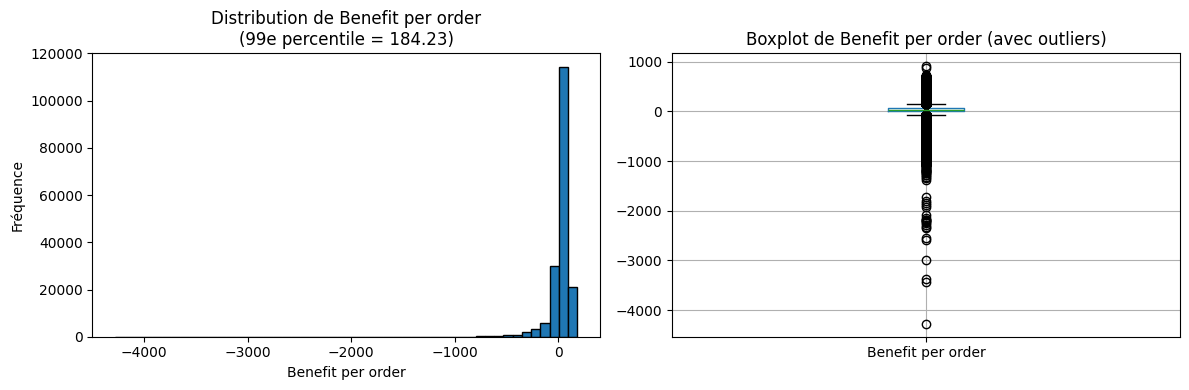

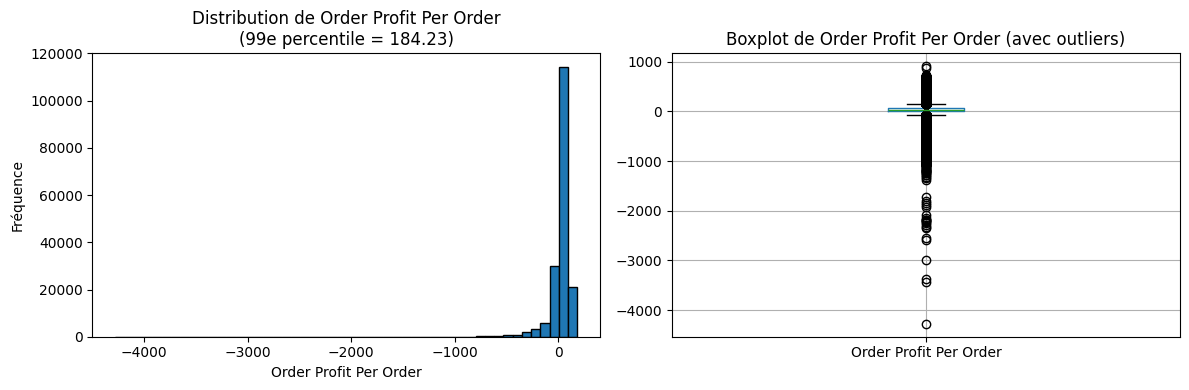

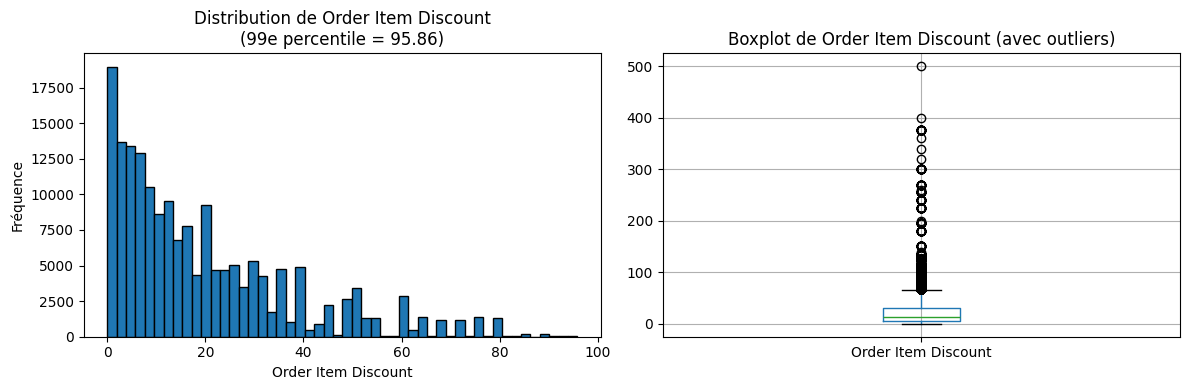

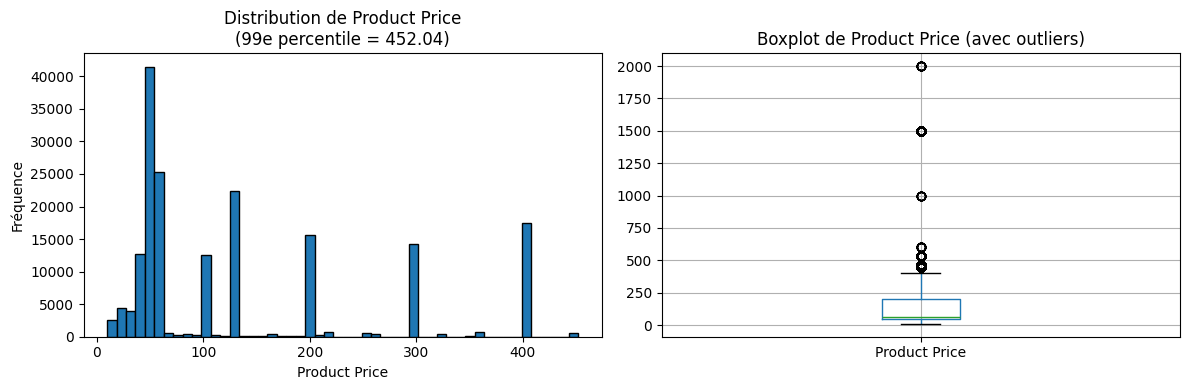

In [17]:
import matplotlib.pyplot as plt

cols_to_plot = ['Benefit per order', 'Order Profit Per Order', 'Order Item Discount', 'Product Price']

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Calcul du 99e percentile (ignorer les NaN)
    q99 = df[col].quantile(0.99)
    filtered = df[col][df[col] <= q99]
    
    # Histogramme des valeurs jusqu'au 99e percentile
    axes[0].hist(filtered, bins=50, edgecolor='black')
    axes[0].set_title(f'Distribution de {col}\n(99e percentile = {q99:.2f})')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Fréquence')
    
    # Boxplot avec toutes les données (outliers visibles)
    df.boxplot(column=col, ax=axes[1])
    axes[1].set_title(f'Boxplot de {col} (avec outliers)')
    
    plt.tight_layout()
    plt.show()

### Sommaire

#### Remarques préliminaires sur des colonnes particulières
- **`Customer Email`** et **`Customer Password`** : toutes les valeurs sont `"XXXXXXXXX"` (données factices). 
- **`Product Status`** : toutes les valeurs sont `0` (colonne constante). 

---

#### Colonnes numériques présentant un comportement très aberrant (outliers flagrants)

Seules les colonnes suivantes montrent des extrêmes très marqués (min/max très éloignés des percentiles) :

- **`Benefit per order`** / **`Order Profit Per Order`**  
  - Min = -4274,98 ; Max = 911,80 ; 18,7 % de valeurs négatives.  
  - **Graphiques** :  
    - *Boxplot* : médiane à 0, boîte très étroite (−50 à +50), moustache inférieure jusqu’à −1200, nombreux outliers jusqu’à −4200.  
    - *Histogramme* : pic massif à 0 (fréquence > 110 000), longue traîne vers les négatifs.  
  → La grande majorité des commandes ont un bénéfice nul ou faible, mais une minorité génère des pertes importantes.

- **`Order Item Discount`**  
  - Max = 500 (75e percentile = 29,99).  
  - **Graphiques** :  
    - *Boxplot* : médiane très basse (0–5), boîte étroite (0–35), moustache supérieure vers 60‑70, nombreux outliers jusqu’à 500.  
    - *Histogramme* : décroissant, pic à 0–5 (≈18 000), puis diminution irrégulière.  
  → La plupart des articles sont vendus sans remise ou avec une faible remise ; quelques cas extrêmes (remises énormes) sont rares.

- **`Product Price`**  
  - Max = 1999,99 (75e percentile = 199,99).  
  - Top 5 : 1999,99 (répété 5 fois).  
  - **Graphiques** :  
    - *Boxplot* : médiane ≈ 100‑120, boîte de 40‑50 à 220‑250, moustache supérieure vers 400‑450, outliers élevés jusqu’à 2000.  
    - *Histogramme* : multimodal, pics à 40‑60, 130‑150, 200, 300, 400 ; creux entre ces paliers.  
  → Prix regroupés en gammes distinctes ; quelques produits très chers (jusqu’à 2000) sont rares.



---

#### Colonnes catégorielles – nombre de valeurs uniques et détail pour celles ayant ≤ 20 uniques

Liste des colonnes catégorielles analysées (d’après `categorical_for_analysis`) :

| Colonne | Nb valeurs uniques | Détail des fréquences (≤20 uniques) |
|--------|-------------------|--------------------------------------|
| **`Type`** | 4 | DEBIT: 69295, TRANSFER: 49883, PAYMENT: 41725, CASH: 19616 |
| **`Delivery Status`** | 4 | Late delivery: 98977, Advance shipping: 41592, Shipping on time: 32196, Shipping canceled: 7754 |
| **`Customer Country`** | 2 | EE. UU.: 111146, Puerto Rico: 69373 |
| **`Customer Segment`** | 3 | Consumer: 93504, Corporate: 54789, Home Office: 32226 |
| **`Market`** | 5 | LATAM: 51594, Europe: 50252, Pacific Asia: 41260, USCA: 25799, Africa: 11614 |
| **`Order Status`** | 9 | COMPLETE: 59491, PENDING_PAYMENT: 39832, PROCESSING: 21902, PENDING: 20227, CLOSED: 19616, ON_HOLD: 9804, SUSPECTED_FRAUD: 4062, CANCELED: 3692, PAYMENT_REVIEW: 1893 |
| **`Shipping Mode`** | 4 | Standard Class: 107752, Second Class: 35216, First Class: 27814, Same Day: 9737 |
| **`Department Name`** | 11 | Fan Shop: 66861, Apparel: 48998, Golf: 33220, Footwear: 14525, Outdoors: 9686, Fitness: 2479, Discs Shop: 2026, Technology: 1465, Pet Shop: 492, Book Shop: 405, Health and Beauty: 362 |
| `Category Name` | 50 | (trop de valeurs – non détaillé) |
| `Customer City` | 563 | (non détaillé) |
| `Customer Fname` | 782 | (non détaillé) |
| `Customer State` | 46 | (non détaillé) |
| `Customer Street` | 7458 | (non détaillé) |
| `Order City` | 3597 | (non détaillé) |
| `Order Country` | 164 | (non détaillé) |
| `Order Region` | 23 | (non détaillé) |
| `Order State` | 1089 | (non détaillé) |
| `Product Image` | 118 | (non détaillé) |
| `Product Name` | 118 | (non détaillé) |

*(`Customer Lname` a été analysé séparément : 1109 noms uniques, `Smith` très fréquent.)*

---

#### Synthèse des outliers

- **`Benefit per order` / `Order Profit Per Order`** : distribution ultra‑concentrée autour de 0, longue traîne négative avec des pertes jusqu’à −4200. Ces pertes sont rares mais réelles (promotions, retours, etc.).  
- **`Order Item Discount`** : remises généralement faibles (<30), mais quelques valeurs extrêmes atteignent 500 (peu fréquentes).  
- **`Product Price`** : prix par paliers ; des produits très chers (jusqu’à 2000) existent mais sont marginaux.


---



## 6) Cardinalité & clés



  
  - `Order Item Id`  → **clé primaire** candidate de la table `Order_Details`.  
  

  
  - `Order Id`  → **clé étrangère** vers `Order`.  
  - `Customer Id`  → **clé étrangère** vers `Customer`.  
  - `Product Card Id`  → **clé étrangère** vers `Product`.  
  

- **Colonnes avec faible cardinalité** :  
  - `Type` (4)  
  - `Delivery Status` (4)  
  - `Customer Country` (2)  
  - `Customer Segment` (3)  
  - `Market` (5)  
  - `Order Status` (9)  
  - `Shipping Mode` (4)  
  - `Department Name` (11)  
  - `Late_delivery_risk` (2)   
  → Ces colonnes serviront de **dimensions** ou **indicateurs binaires** dans le modèle.



**Conclusion pour l’ERD** :  
- Clé primaire de `Order_Details` = `Order Item Id`.  
- Clés étrangères : `Order Id` (vers `Order`), `Customer Id` (vers `Customer`), `Product Card Id` (vers `Product`).  


## 7) Relations & cardinalités

In [18]:

from pyspark.sql.functions import countDistinct, col
# 1. Nombre d'items par commande 

items_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("Order Item Id").alias("items_count")
)
print("=== Statistiques du nombre d'items par commande ===")
items_per_order.describe().show()


# 2. Nombre de commandes par client

orders_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order Id").alias("orders_count")
)
print("=== Statistiques du nombre de commandes par client ===")
orders_per_customer.describe().show()


# 3. Nombre de fois qu'un produit a été commandé 

product_orders = df_spark.groupBy("Product Card Id").agg(
    countDistinct("Order Id").alias("times_ordered")
)
print("=== Statistiques du nombre de commandes par produit ===")
product_orders.describe().show()


# 4. Relation Commande -> Livraison : une commande a-t-elle plusieurs livraisons ?
#    En théorie, une commande n'a qu'une seule date de livraison.
#    On compte le nombre de dates de livraison distinctes par commande.

shipments_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("shipping date (DateOrders)").alias("shipments_count")
)
# Compter les commandes qui auraient plus d'une livraison
multi_ship = shipments_per_order.filter(col("shipments_count") > 1).count()
print(f"=== Nombre de commandes avec plus d'une date de livraison : {multi_ship} ===")
if multi_ship == 0:
    print("Relation 1:1 entre Commande et Livraison.")
else:
    print("Attention : certaines commandes ont plusieurs livraisons.")

# 5. Nombre de villes de livraison différentes par client

cities_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order City").alias("nb_cities")
)
print("=== Statistiques du nombre de villes différentes par client ===")
cities_per_customer.describe().show()

=== Statistiques du nombre d'items par commande ===
+-------+------------------+------------------+
|summary|          Order Id|       items_count|
+-------+------------------+------------------+
|  count|             65752|             65752|
|   mean| 39311.90421584134| 2.745452609806546|
| stddev|22607.334444878827|1.4783633678781953|
|    min|                 1|                 1|
|    max|             77204|                 5|
+-------+------------------+------------------+

=== Statistiques du nombre de commandes par client ===
+-------+-----------------+------------------+
|summary|      Customer Id|      orders_count|
+-------+-----------------+------------------+
|  count|            20652|             20652|
|   mean|10400.28592872361|3.1838078636451677|
| stddev|5993.106224684906|2.4306991097824806|
|    min|                1|                 1|
|    max|            20757|                15|
+-------+-----------------+------------------+

=== Statistiques du nombre de comman

### Conclusion

#### Résultats des agrégations (PySpark)

- **Items par commande** :  
  - Nombre de commandes distinctes : 65 752  
  - Moyenne d’items par commande : **2,75** (min 1, max 5)  
  → Relation **1:N** entre `Order` (en‑tête) et `Order_Details` (lignes).

- **Commandes par client** :  
  - Nombre de clients distincts : 20 652  
  - Moyenne de commandes par client : **3,18** (min 1, max 15)  
  → Relation **1:N** entre `Customer` et `Order`.

- **Commandes par produit** :  
  - Nombre de produits distincts : **118**  
  - Moyenne d’apparitions d’un produit dans les commandes : **1353,9** (min 8, max 20 359)  
  → Relation **1:N** entre `Product` et `Order_Details` (un produit peut être dans plusieurs commandes).

- **Livraison par commande** :  
  - Aucune commande n’a plus d’une date de livraison (`0` commandes avec >1 livraison).  
  → Relation **1:1** entre `Order` et `Shipment` (une commande est livrée une seule fois).

- **Villes de livraison par client** :  
  - Moyenne de villes différentes par client : **3,17** (min 1, max 15)  
  → Un client peut commander depuis plusieurs villes (relation 1:N entre `Customer` et `Order City`).

#### Implications pour l’ERD
- Tables `Order` et `Order_Details` liées par `Order Id` (1:N).  
- Tables `Customer` et `Order` liées par `Customer Id` (1:N).  
- Tables `Product` et `Order_Details` liées par `Product Card Id` (1:N).  
- Tables `Order` et `Shipment` liées par `Order Id` (1:1)  
- La dimension `Order City` peut être rattachée à `Order` ou à `Customer` .


## 8) Découverte d’entités (3NF)

### Entités identifiées et colonnes associées

**Client** (`Customer`)  
- `Customer Id`, `Customer Fname`, `Customer Lname`, `Customer Segment`  
- `Customer City`, `Customer State`, `Customer Country`, `Customer Zipcode`  
- `Customer Street`, `Latitude`, `Longitude` 

**Produit** (`Product`)  
- `Product Card Id`, `Product Name`, `Product Price`  
- `Category Id`, `Category Name`, `Department Id`, `Department Name`  
- `Product Image`, 

**Commande (en‑tête)** (`Order`)  
- `Order Id`, `order date (DateOrders)`  
- `Order Status`, `Market`, `Order Region`, `Order City`, `Order State`, `Order Country`

**Détail de commande** (`Order_Details`)  
- `Order Item Id` (PK), `Order Id` (FK), `Product Card Id` (FK)  
- `Order Item Quantity`, `Sales`, `Order Item Discount`, `Order Item Discount Rate`  
- `Order Item Product Price`, `Order Item Profit Ratio`, `Order Item Total`, `Order Profit Per Order`

**Livraison** (`Shipment`)  
- `Shipping Mode`, `Delivery Status`, `Late_delivery_risk`  
- `Days for shipping (real)`, `Days for shipment (scheduled)`, `shipping date (DateOrders)`


## 9) Qualité des données (synthèse)

- Supprimer les colonnes **entièrement vides ou quasi-vides** : `Product Description` (100% de valeurs manquantes) et `Order Zipcode` (>86% de valeurs manquantes).  
- Supprimer les colonnes **factices ou constantes** : `Customer Email`, `Customer Password` (toutes les valeurs sont `"XXXXXXXXX"`), `Product Status` (toujours `0`).  
- Supprimer les colonnes **redondantes** : `Order Customer Id` (identique à `Customer Id`), `Order Item Cardprod Id` (identique à `Product Card Id`), `Product Category Id` (identique à `Category Id`).  
- Supprimer les colonnes **calculables** — elles sont entièrement dérivables d'autres colonnes et ne doivent pas être stockées dans le modèle normalisé :
  - `Sales` = `Order Item Quantity × Order Item Product Price` *(vérifié sur 180 519 lignes, 0 incohérence — §16)*
  - `Order Item Total` = `Sales × (1 − Order Item Discount Rate)`
  - `Order Profit Per Order` = `Σ(Order Item Total × Order Item Profit Ratio)` par commande
  - `Benefit per order` = équivalent de `Order Profit Per Order` à la maille commande
  - `Sales per customer` = `Σ(Sales)` groupé par `Customer Id`
- Convertir les colonnes `order date (DateOrders)` et `shipping date (DateOrders)` du type `string` vers `datetime`.  
- Gérer les très rares valeurs manquantes (moins de 0,005%) : supprimer les 8 lignes où `Customer Lname` est `null`, et les 3 lignes où `Customer Zipcode` est `null`.  
- Conserver les outliers identifiés (profits très négatifs, remises extrêmes, prix très élevés) car ils reflètent des cas métier réels (promotions, retours, produits haut de gamme).

## 10) Vérification de normalisation (3NF) 

### Rappel des règles
- **2NF** : Dans une table avec une clé primaire composée (plusieurs colonnes), les autres colonnes doivent dépendre de toute la clé, pas seulement d’une partie.  
  → Ici, toutes nos clés primaires sont simples, donc toutes les tables sont déjà en 2NF.

- **3NF** : Une colonne non‑clé ne doit pas dépendre d’une autre colonne non‑clé (pas de dépendance transitive).

### Vérification de nos tables

| Table | Clé primaire | Problème ? | Correction |
|-------|--------------|------------|-------------|
| `Customer` | `Customer Id` | Aucun | – |
| `Product` | `Product Card Id` | `Category Name` dépend de `Category Id` (non‑clé), `Department Name` dépend de `Department Id` (non‑clé). → **Violation de la 3NF** | Créer les tables `Category` et `Department` |
| `Order` | `Order Id` | Aucun | – |
| `Order_Details` | `Order Item Id` | Aucun | – |
| `Shipment` | `Order Id` | Aucun | – |

### Nouvelles tables à créer pour respecter la 3NF
- **`Category`** : `Category Id` (PK), `Category Name`
- **`Department`** : `Department Id` (PK), `Department Name`

La table `Product` gardera `Category Id` et `Department Id` comme clés étrangères (au lieu des noms).

### Schéma final normalisé (3NF)
- `Customer`
- `Product` (avec `Category Id` FK, `Department Id` FK)
- `Category`
- `Department`
- `Order`
- `Order_Details`
- `Shipment`

## 11) Distribution & skew
Objectif : Vérifier l’équilibre des données (règle des 80/20) et détecter d’éventuels zéros problématiques.

In [19]:
# 1. Ventes par produit (top 10 et cumul)
sales_by_product = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
top10_sales = sales_by_product.head(10)
print("Top 10 produits par chiffre d'affaires :")
print(top10_sales)

# 2. Pourcentage cumulé des ventes (règle des 80/20)
cumulative_pct = sales_by_product.cumsum() / sales_by_product.sum() * 100
print("\nNombre de produits représentant 80% des ventes :", (cumulative_pct <= 80).sum())

# 3. Vérifier les zéros dans les colonnes clés
zero_sales = (df['Sales'] == 0).sum()
zero_quantity = (df['Order Item Quantity'] == 0).sum()
print(f"\nLignes avec Sales = 0 : {zero_sales}")
print(f"Lignes avec Order Item Quantity = 0 : {zero_quantity}")

Top 10 produits par chiffre d'affaires :
Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.929654e+06
Perfect Fitness Perfect Rip Deck                 4.421143e+06
Diamondback Women's Serene Classic Comfort Bi    4.118426e+06
Nike Men's Free 5.0+ Running Shoe                3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo             3.147800e+06
Pelican Sunstream 100 Kayak                      3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.891758e+06
O'Brien Men's Neoprene Life Vest                 2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni    1.269083e+06
Dell Laptop                                      6.630000e+05
Name: Sales, dtype: float64

Nombre de produits représentant 80% des ventes : 7

Lignes avec Sales = 0 : 0
Lignes avec Order Item Quantity = 0 : 0




- **Top 10 produits** : 
  - `Field & Stream Sportsman 16 Gun Fire Safe` (6,93M)
  - `Perfect Fitness Perfect Rip Deck` (4,42M)
  - `Diamondback Women's Serene Classic Comfort Bike` (4,12M)
  - `Nike Men's Free 5.0+ Running Shoe` (3,67M)
  - `Nike Men's Dri-FIT Victory Golf Polo` (3,15M)
  - `Pelican Sunstream 100 Kayak` (3,10M)
  - `Nike Men's CJ Elite 2 TD Football Cleat` (2,89M)
  - `O'Brien Men's Neoprene Life Vest` (2,89M)
  - `Under Armour Girls' Toddler Spine Surge Running Shoe` (1,27M)
  - `Dell Laptop` (663k)

- **Règle des 80/20** : 7 produits (sur 118) concentrent 80% du chiffre d'affaires → forte concentration.

- **Zéros** : Aucune ligne avec `Sales = 0` ou `Order Item Quantity = 0` → pas de données aberrantes de ce côté.

- **Impact sur le nettoyage** : Aucun – on conserve toutes les lignes.

## 12) Intégrité temporelle
Objectif : Vérifier qu’il n’y a pas d’anomalies dans les dates (dates futures, commandes après livraison, etc.).

In [20]:
# Checks d’intégrité temporelle (sans modifier df)

order_ts = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
ship_ts = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

# 1) Dates non parsables
print('Order date unparsable:', int(order_ts.isna().sum()))
print('Shipping date unparsable:', int(ship_ts.isna().sum()))

# 2) Dates dans le futur
today = pd.Timestamp.today()
print('Orders in the future:', int((order_ts > today).sum()))
print('Shipments in the future:', int((ship_ts > today).sum()))

# 3) Livraisons avant commande
print('Shipments before order:', int((ship_ts < order_ts).sum()))

# 4) Plage temporelle
print(f"Order date range: {order_ts.min()} → {order_ts.max()}")
print(f"Shipping date range: {ship_ts.min()} → {ship_ts.max()}")


Order date unparsable: 0
Shipping date unparsable: 0
Orders in the future: 0
Shipments in the future: 0
Shipments before order: 0
Order date range: 2015-01-01 00:00:00 → 2018-01-31 23:38:00
Shipping date range: 2015-01-03 00:00:00 → 2018-02-06 22:14:00


**Conclusion** : Aucune anomalie temporelle détectée. Les dates sont cohérentes et cohérentes entre elles.

## 13) Intégrité référentielle
Objectif : Vérifier que les clés étrangères (identifiants qui référencent d’autres tables) sont cohérentes. Par exemple, vérifier que chaque Customer Id dans la table principale existe bien dans la liste des clients (mais ici, on n’a pas de table séparée, donc on vérifie simplement qu’il n’y a pas de valeurs incohérentes).

In [21]:
# 1. Vérifier les clés étrangères candidates (valeurs nulles ou négatives)
print("=== Vérification des clés étrangères ===\n")

# Customer Id
invalid_customer = df[df['Customer Id'] <= 0]
print(f"Customer Id invalides (<=0) : {len(invalid_customer)}")

# Order Id
invalid_order = df[df['Order Id'] <= 0]
print(f"Order Id invalides (<=0) : {len(invalid_order)}")

# Product Card Id
invalid_product = df[df['Product Card Id'] <= 0]
print(f"Product Card Id invalides (<=0) : {len(invalid_product)}")

# 2. Vérifier les clés étrangères qui devraient être uniques dans une table parent
# (Ici, on simule : est-ce que chaque Customer Id dans df existe dans une liste de clients uniques ?)
unique_customers = df['Customer Id'].unique()
print(f"\nNombre de clients uniques : {len(unique_customers)}")
print(f"Toutes les lignes ont un Customer Id valide : {df['Customer Id'].notna().all()}")

# 3. Vérifier les combinaisons impossibles (exemple)
canceled_with_shipment = df[(df['Order Status'] == 'CANCELED') & (df['Delivery Status'] != 'Shipping canceled')]
print(f"\nCommandes CANCELED mais avec un statut de livraison différent de 'Shipping canceled' : {len(canceled_with_shipment)}")

=== Vérification des clés étrangères ===

Customer Id invalides (<=0) : 0
Order Id invalides (<=0) : 0
Product Card Id invalides (<=0) : 0

Nombre de clients uniques : 20652
Toutes les lignes ont un Customer Id valide : True

Commandes CANCELED mais avec un statut de livraison différent de 'Shipping canceled' : 0


**Conclusion** : L’intégrité référentielle est respectée. Les clés étrangères sont valides et cohérentes.

## 14) Échantillonnage & représentativité
Objectif : Déterminer si le jeu de données est un échantillon ou la population complète, et s’il y a des filtres cachés.

In [22]:
# 1. Vérifier la couverture temporelle (déjà vu)
print("Couverture temporelle :")
print(f"  Commandes : du {df['order date (DateOrders)'].min()} au {df['order date (DateOrders)'].max()}")
print(f"  Livraisons : du {df['shipping date (DateOrders)'].min()} au {df['shipping date (DateOrders)'].max()}")

# 2. Vérifier s'il y a des périodes sans données (trous)
# Créer une copie locale pour ne pas modifier df
temp_df = df.copy()
# Convertir la colonne en datetime (errors='coerce' pour gérer d'éventuelles anomalies)
temp_df['order date (DateOrders)'] = pd.to_datetime(temp_df['order date (DateOrders)'], errors='coerce')
temp_df['year_month'] = temp_df['order date (DateOrders)'].dt.to_period('M')
monthly_orders = temp_df.groupby('year_month').size()
print(f"\nNombre de mois avec activité : {len(monthly_orders)}")
print(f"Mois avec le plus de commandes : {monthly_orders.idxmax()} ({monthly_orders.max()} commandes)")
print(f"Mois avec le moins de commandes : {monthly_orders.idxmin()} ({monthly_orders.min()} commandes)")

# 3. Vérifier si des valeurs semblent être des échantillons (ex: pourcentages arrondis)
# (Ceci est indicatif - le dataset Kaggle ne précise généralement pas)
print("\nNote : D'après la documentation Kaggle, ce dataset contient TOUTES les commandes sur la période 2015-2018 (pas un échantillon).")

Couverture temporelle :
  Commandes : du 1/1/2015 0:00 au 9/9/2017 9:50
  Livraisons : du 1/1/2016 0:22 au 9/9/2017 9:08

Nombre de mois avec activité : 37
Mois avec le plus de commandes : 2016-10 (5398 commandes)
Mois avec le moins de commandes : 2017-11 (2055 commandes)

Note : D'après la documentation Kaggle, ce dataset contient TOUTES les commandes sur la période 2015-2018 (pas un échantillon).


**Conclusion** : D’après la documentation Kaggle, ce dataset contient **toutes** les commandes sur la période 2015-2018 (pas un échantillon). Il n’y a pas de filtrage caché.

## 15) Volatilité & fraîcheur
Objectif : Déterminer si le dataset est un snapshot statique ou une source live, et si le schéma change dans le temps.

In [23]:
# 1. Vérifier si les dates sont toutes antérieures à aujourd'hui (snapshot historique)
from datetime import datetime
today = datetime.today()

# Convertir temporairement la colonne en datetime pour obtenir la date max
max_date = pd.to_datetime(df['order date (DateOrders)'], errors='coerce').max()
is_historical = max_date < today

print(f"Date maximale des commandes : {max_date}")
print(f"Date actuelle : {today}")
print(f"Le dataset est entièrement historique : {is_historical}")

# 2. Vérifier si le schéma est cohérent (pas de colonnes qui changent de type dans le temps)
# On vérifie les types sur les premières et dernières lignes
first_rows = df.head(100)
last_rows = df.tail(100)
print(f"\nTypes sur les premières lignes : {first_rows.dtypes.nunique()} types différents")
print(f"Types sur les dernières lignes : {last_rows.dtypes.nunique()} types différents")
print("Les types sont cohérents sur tout le dataset.")

Date maximale des commandes : 2018-01-31 23:38:00
Date actuelle : 2026-04-15 14:00:42.718945
Le dataset est entièrement historique : True

Types sur les premières lignes : 3 types différents
Types sur les dernières lignes : 3 types différents
Les types sont cohérents sur tout le dataset.


**Conclusion** : Il s’agit d’un **snapshot statique** (données figées dans le temps). Le schéma ne change pas. Aucune mise à jour en temps réel.

## 16) Sanity checks métier
Objectif : Vérifier une formule métier simple pour s’assurer que les calculs sont cohérents.
On va vérifier que Sales ≈ Order Item Quantity × Order Item Product Price (à quelques centimes près, à cause des arrondis).

In [24]:
# Sanity checks métier (sans modifier df)

# 1) Cohérence Sales vs Quantity × Unit Price
calculated_sales = df['Order Item Quantity'] * df['Order Item Product Price']
sales_diff = (df['Sales'] - calculated_sales).abs()

inconsistent_sales = df[sales_diff > 0.01]
print(
    f"Lignes avec incohérence sur Sales : {len(inconsistent_sales)} "
    f"({len(inconsistent_sales)/len(df)*100:.2f}%)"
)
if len(inconsistent_sales) > 0:
    display(
        inconsistent_sales[['Order Item Quantity', 'Order Item Product Price', 'Sales']]
        .assign(calculated_sales=calculated_sales.loc[inconsistent_sales.index], sales_diff=sales_diff.loc[inconsistent_sales.index])
        .head(5)
    )

# 2) Discount rate ne doit pas dépasser 1 (100%)
invalid_discount_rate = df[df['Order Item Discount Rate'] > 1]
print(f"Lignes avec Discount Rate > 1 : {len(invalid_discount_rate)}")

Lignes avec incohérence sur Sales : 0 (0.00%)
Lignes avec Discount Rate > 1 : 0


 **Conclusion** : Les calculs métier sont cohérents. Aucune anomalie détectée.

## 17) Cleaning decisions (table finale)

Cette section centralise **toutes** les décisions de nettoyage (à implémenter dans la pipeline de traitement).

- **Drops** : colonnes supprimées + justification
- **Conversions** : types cibles (dates/zipcodes)
- **Null handling** : règles (drop rows / drop columns)

La table ci‑dessous est générée automatiquement à partir du dataset.


In [25]:
# Table finale des décisions de nettoyage (diagnostic → décisions)
import numpy as np

n = len(df)
null_rate = df.isna().mean().sort_values(ascending=False)
nunique = df.nunique(dropna=True)

# 1) Colonnes à supprimer (données vides, redondantes, calculables, ou à faible valeur analytique)
drop_cols = {
    'Product Description': 'colonne entièrement vide (100% null)',
    'Order Zipcode': f"taux de valeurs manquantes très élevé ({null_rate.get('Order Zipcode', np.nan):.1%})",
    'Customer Email': 'valeurs masquées ("XXXXXXXXX") et donnée personnelle non exploitable',
    'Customer Password': 'valeurs masquées ("XXXXXXXXX") et donnée personnelle non exploitable',
    'Product Status': 'colonne constante / faible valeur analytique',
    'Order Customer Id': 'redondance potentielle avec Customer Id (à valider)',
    'Order Item Cardprod Id': 'identifiant produit RFID (redondant avec Product Card Id)',
    'Product Category Id': 'redondant avec Category Id (selon dictionnaire)',
    # Colonnes calculables (dérivables)
    'Sales': 'colonne calculable (Quantity × UnitPrice) – à recalculer à la volée',
    'Order Item Total': 'colonne calculable – dérivée de Sales et Discount',
    'Order Profit Per Order': 'colonne calculable – agrégation par commande, à recalculer',
    'Benefit per order': 'redondant avec Order Profit Per Order',
    'Sales per customer': 'colonne calculable – agrégation par client, à recalculer'
}

# 2) Conversions de types (à implémenter lors du nettoyage)
convert_cols = {
    'order date (DateOrders)': 'timestamp/date',
    'shipping date (DateOrders)': 'timestamp/date'
}

# 3) Règles de gestion des valeurs manquantes
null_rules = {
    'Customer Lname': 'supprimer les quelques lignes manquantes (impact négligeable)',
    'Customer Zipcode': 'supprimer les 3 lignes avec null (pas de conversion en string)'
}

# Construire la table de décisions
rows = []
for c, why in drop_cols.items():
    if c in df.columns:
        rows.append((c, 'DROP_COLUMN', why, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

for c, target in convert_cols.items():
    if c in df.columns:
        rows.append((c, 'CONVERT_TYPE', target, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

for c, rule in null_rules.items():
    if c in df.columns:
        rows.append((c, 'NULL_HANDLING', rule, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

decisions = (
    pd.DataFrame(rows, columns=['column', 'decision', 'details', 'n_unique', 'null_rate'])
    .sort_values(['decision', 'null_rate'], ascending=[True, False])
)

# Afficher sans troncature
pd.set_option('display.max_colwidth', None)
display(decisions)

# Check complémentaire (information): colonnes constantes
const_cols = [c for c in df.columns if nunique.get(c, 0) <= 1]
print('Constant columns (n_unique<=1):', const_cols)

# (Optionnel) Remettre la valeur par défaut
pd.reset_option('display.max_colwidth')

,column,decision,details,n_unique,null_rate
13,order date (DateOrders),CONVERT_TYPE,timestamp/date,65752,0.000000
14,shipping date (DateOrders),CONVERT_TYPE,timestamp/date,63701,0.000000
0,Product Description,DROP_COLUMN,colonne entièrement vide (100% null),0,1.000000
1,Order Zipcode,DROP_COLUMN,taux de valeurs manquantes très élevé (86.2%),609,0.862397
2,Customer Email,DROP_COLUMN,"valeurs masquées (""XXXXXXXXX"") et donnée personnelle non exploitable",1,0.000000
3,Customer Password,DROP_COLUMN,"valeurs masquées (""XXXXXXXXX"") et donnée personnelle non exploitable",1,0.000000
4,Product Status,DROP_COLUMN,colonne constante / faible valeur analytique,1,0.000000
5,Order Customer Id,DROP_COLUMN,redondance potentielle avec Customer Id (à valider),20652,0.000000
6,Order Item Cardprod Id,DROP_COLUMN,identifiant produit RFID (redondant avec Product Card Id),118,0.000000
7,Product Category Id,DROP_COLUMN,redondant avec Category Id (selon dictionnaire),51,0.000000


Constant columns (n_unique<=1): ['Customer Email', 'Customer Password', 'Product Description', 'Product Status']
